# Word Count — Pure PySpark MapReduce
### 100% Spark: RDD → DataFrame → Spark SQL → Spark Visualisation
**No pandas | No for loops | No manual iteration**

## Step 0 — Create Spark Session & Context

In [ ]:

import os
import urllib.request
import ssl

data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

data_dir1 = "hadoop/bin"
os.makedirs(data_dir1, exist_ok=True)

urls_and_paths = {
    "https://raw.githubusercontent.com/Yadav-Raj-Ghimire/BigData_work/refs/heads/main/spark-config/test.txt": os.path.join(data_dir, "test.txt"),
    "https://github.com/Yadav-Raj-Ghimire/BigData_work/tree/main/spark-config/hadoop/bin/winutils.exe": os.path.join(data_dir1, "winutils.exe"),
    "https://github.com/Yadav-Raj-Ghimire/BigData_work/tree/main/spark-config/hadoop/bin/hadoop.dll": os.path.join(data_dir1, "hadoop.dll")
}


# Create an unverified SSL context
ssl_context = ssl._create_unverified_context()

for url, path in urls_and_paths.items():
    # Use the unverified context with urlopen
    with urllib.request.urlopen(url, context=ssl_context) as response, open(path, 'wb') as out_file:
        data = response.read()
        out_file.write(data)
import os, urllib.request, ssl; ssl_context = ssl._create_unverified_context(); [open(path, 'wb').write(urllib.request.urlopen(url, context=ssl_context).read())]


# ======================================================================================

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, LinearSVC, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.ml.linalg import Vectors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

python_path = sys.executable
os.environ['PYSPARK_PYTHON'] = python_path
os.environ['HADOOP_HOME'] ="hadoop"
os.environ['JAVA_HOME'] = r'C:\Users\yrghimire\.jdks\corretto-1.8.0_482'
######################🔴🔴🔴################################

#os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages com.datastax.spark:spark-cassandra-connector_2.12:3.5.1 pyspark-shell'
#os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-avro_2.12:3.5.4 pyspark-shell'
#os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.4 pyspark-shell'


conf = SparkConf().setAppName("BigData Assignment 1").setMaster("local[*]").set("spark.driver.host","localhost").set("spark.default.parallelism", "4").set("spark.sql.codegen.wholeStage","false").set("spark.sql.codegen.maxFields","200").set("spark.driver.memory","32g").set("spark.driver.maxResultSize","8g")

sc = SparkContext(conf=conf)

spark = SparkSession.builder.getOrCreate()

spark.read.format("csv").load("data/test.txt").toDF("Success").show(20, False)


##################🔴🔴🔴🔴🔴🔴 -> DONT TOUCH ABOVE CODE -- TYPE BELOW ####################################

print()


+---------------------+
|Success              |
+---------------------+
|Spark Journey Started|
+---------------------+




## Step 1 — Write wc.txt Dataset to Disk

## Step 2 — Read File → RDD (one element per line)
> `sc.textFile()` loads the file into a distributed RDD — each line is one RDD element

In [2]:
# ── SPARK RDD: Read text file ─────────────────────────────────────────────────
lines_rdd = sc.textFile('Dataset/wc.txt')

print('RDD type  :', type(lines_rdd))
print('Partitions:', lines_rdd.getNumPartitions())
print('Total lines:', lines_rdd.count())

# Show first 3 lines using Spark RDD action (no for loop)
lines_rdd.take(3)

RDD type  : <class 'pyspark.rdd.RDD'>
Partitions: 2
Total lines: 44


['word count from Wikipedia the free encyclopedia',
 'the word count is the number of words in a document or passage of text Word counting may be needed when a text',
 'is required to stay within certain numbers of words This may particularly be the case in academia legal']

## Step 3 — MAP: Split Lines into Words (flatMap)
> `flatMap` applies split to every line AND flattens nested lists into a single word stream

In [4]:
# ── SPARK RDD: flatMap — split lines into cleaned, lowercased words ────────────
words_rdd = (
    lines_rdd
    .flatMap(lambda line: line.lower().split())
    .map(lambda word: ''.join(c for c in word if c.isalpha()))
    .filter(lambda word: len(word) > 1)
)

print('Total words (with duplicates):', words_rdd.count())
print('Sample words:')
words_rdd.take(15)

Total words (with duplicates): 781
Sample words:


['word',
 'count',
 'from',
 'wikipedia',
 'the',
 'free',
 'encyclopedia',
 'the',
 'word',
 'count',
 'is',
 'the',
 'number',
 'of',
 'words']

## Step 4 — MAP: Each Word → (word, 1) Tuple
> This is the **Map** step of MapReduce — assign a count of 1 to every word

In [5]:
# ── SPARK RDD: map — emit (word, 1) pairs ─────────────────────────────────────
pairs_rdd = words_rdd.map(lambda word: (word, 1))

print('RDD type:', type(pairs_rdd))
print('Sample (word, 1) pairs:')
pairs_rdd.take(10)

RDD type: <class 'pyspark.rdd.PipelinedRDD'>
Sample (word, 1) pairs:


[('word', 1),
 ('count', 1),
 ('from', 1),
 ('wikipedia', 1),
 ('the', 1),
 ('free', 1),
 ('encyclopedia', 1),
 ('the', 1),
 ('word', 1),
 ('count', 1)]

## Step 5 — REDUCE: reduceByKey → Sum all 1s per Word
> This is the **Reduce** step — Spark shuffles keys across partitions and sums counts

In [6]:
# ── SPARK RDD: reduceByKey — aggregate counts per word ───────────────────────
word_count_rdd = pairs_rdd.reduceByKey(lambda a, b: a + b)

print('Unique words found:', word_count_rdd.count())
print('Sample (word, count):')
word_count_rdd.take(10)

Unique words found: 357
Sample (word, count):


[('free', 1),
 ('of', 25),
 ('in', 15),
 ('counting', 6),
 ('may', 8),
 ('when', 3),
 ('numbers', 1),
 ('particularly', 1),
 ('used', 4),
 ('job', 1)]

## Step 6 — Convert RDD → Spark DataFrame
> Use `spark.createDataFrame()` with explicit schema — no pandas involved

In [8]:
# ── RDD → Spark DataFrame using explicit schema ───────────────────────────────

from pyspark.sql.types import StructType, StructField, StringType, IntegerType

schema = StructType([
    StructField('word',  StringType(),  nullable=False),
    StructField('count', IntegerType(), nullable=False)
])

word_count_df = spark.createDataFrame(word_count_rdd, schema=schema)

print('DataFrame schema:')
word_count_df.printSchema()
print(f'Total rows in DataFrame: {word_count_df.count()}')
word_count_df.show(10, truncate=False)

DataFrame schema:
root
 |-- word: string (nullable = false)
 |-- count: integer (nullable = false)

Total rows in DataFrame: 357
+------------+-----+
|word        |count|
+------------+-----+
|free        |1    |
|of          |25   |
|in          |15   |
|counting    |6    |
|may         |8    |
|when        |3    |
|numbers     |1    |
|particularly|1    |
|used        |4    |
|job         |1    |
+------------+-----+
only showing top 10 rows



## Step 7 — Sort & Filter using Spark DataFrame API
> Pure Spark column operations — `.orderBy()`, `.filter()`, `.withColumn()`

In [10]:
# ── Sorted DataFrame — Top 30 words ──────────────────────────────────────────
from pyspark.sql import functions as F

top_words_df = (
    word_count_df
    .orderBy(F.col('count').desc())
    .withColumn('rank', F.monotonically_increasing_id() + 1)
)

print('TOP 30 MOST FREQUENT WORDS:')
top_words_df.show(30, truncate=False)

# ── Words appearing more than 5 times ────────────────────────────────────────
print('Words appearing MORE THAN 5 TIMES:')
word_count_df.filter(F.col('count') > 5).orderBy(F.col('count').desc()).show(truncate=False)

TOP 30 MOST FREQUENT WORDS:
+--------+-----+----+
|word    |count|rank|
+--------+-----+----+
|the     |43   |1   |
|word    |28   |2   |
|of      |25   |3   |
|and     |23   |4   |
|words   |21   |5   |
|to      |19   |6   |
|is      |19   |7   |
|in      |15   |8   |
|count   |11   |9   |
|as      |11   |10  |
|or      |11   |11  |
|for     |10   |12  |
|text    |9    |13  |
|may     |8    |14  |
|be      |8    |15  |
|such    |7    |16  |
|on      |7    |17  |
|counting|6    |18  |
|novel   |6    |19  |
|length  |5    |20  |
|by      |5    |21  |
|most    |5    |22  |
|that    |5    |23  |
|rules   |5    |24  |
|also    |5    |25  |
|fiction |5    |26  |
|can     |5    |27  |
|used    |4    |28  |
|details |4    |29  |
|are     |4    |30  |
+--------+-----+----+
only showing top 30 rows

Words appearing MORE THAN 5 TIMES:
+--------+-----+
|word    |count|
+--------+-----+
|the     |43   |
|word    |28   |
|of      |25   |
|and     |23   |
|words   |21   |
|is      |19   |
|to      |

## Step 8 — Spark SQL: Register as TempView & Query with SQL
> Register the DataFrame as a SQL table and query with pure Spark SQL

In [11]:
# ── Register as Spark SQL TempView ───────────────────────────────────────────
word_count_df.createOrReplaceTempView('word_counts')

# Query 1: Top 20 words
print('=== SQL Query 1: Top 20 Words ===')
spark.sql("""
    SELECT word, count
    FROM   word_counts
    ORDER  BY count DESC
    LIMIT  20
""").show(truncate=False)

# Query 2: Total word count, unique words, avg frequency
print('=== SQL Query 2: Summary Statistics ===')
spark.sql("""
    SELECT
        COUNT(DISTINCT word)  AS unique_words,
        SUM(count)            AS total_words,
        ROUND(AVG(count), 2)  AS avg_frequency,
        MAX(count)            AS max_count,
        MIN(count)            AS min_count
    FROM word_counts
""").show(truncate=False)

# Query 3: Words that appear exactly once
print('=== SQL Query 3: Words appearing only ONCE (hapax legomena) ===')
spark.sql("""
    SELECT COUNT(*) AS hapax_count
    FROM   word_counts
    WHERE  count = 1
""").show()

=== SQL Query 1: Top 20 Words ===
+--------+-----+
|word    |count|
+--------+-----+
|the     |43   |
|word    |28   |
|of      |25   |
|and     |23   |
|words   |21   |
|is      |19   |
|to      |19   |
|in      |15   |
|or      |11   |
|count   |11   |
|as      |11   |
|for     |10   |
|text    |9    |
|may     |8    |
|be      |8    |
|on      |7    |
|such    |7    |
|counting|6    |
|novel   |6    |
|by      |5    |
+--------+-----+

=== SQL Query 2: Summary Statistics ===
+------------+-----------+-------------+---------+---------+
|unique_words|total_words|avg_frequency|max_count|min_count|
+------------+-----------+-------------+---------+---------+
|357         |781        |2.19         |43       |1        |
+------------+-----------+-------------+---------+---------+

=== SQL Query 3: Words appearing only ONCE (hapax legomena) ===
+-----------+
|hapax_count|
+-----------+
|        250|
+-----------+



## Step 9 — Spark DataFrame: Word Length Analysis
> Use Spark built-in functions — `F.length()`, `F.avg()`, `F.groupBy()` — zero pandas

In [12]:
# ── Add word_length column using Spark function ───────────────────────────────
enriched_df = (
    word_count_df
    .withColumn('word_length', F.length(F.col('word')))
    .withColumn('freq_label',
        F.when(F.col('count') >= 10, 'High')
         .when(F.col('count') >= 5,  'Medium')
         .otherwise('Low'))
)

print('Enriched DataFrame with word_length and freq_label:')
enriched_df.orderBy(F.col('count').desc()).show(15, truncate=False)

# Average word length grouped by frequency label
print('Average word length by frequency category:')
enriched_df.groupBy('freq_label').agg(
    F.count('word').alias('num_words'),
    F.round(F.avg('word_length'), 2).alias('avg_word_len'),
    F.sum('count').alias('total_occurrences')
).orderBy('total_occurrences', ascending=False).show()

Enriched DataFrame with word_length and freq_label:
+-----+-----+-----------+----------+
|word |count|word_length|freq_label|
+-----+-----+-----------+----------+
|the  |43   |3          |High      |
|word |28   |4          |High      |
|of   |25   |2          |High      |
|and  |23   |3          |High      |
|words|21   |5          |High      |
|is   |19   |2          |High      |
|to   |19   |2          |High      |
|in   |15   |2          |High      |
|count|11   |5          |High      |
|or   |11   |2          |High      |
|as   |11   |2          |High      |
|for  |10   |3          |High      |
|text |9    |4          |Medium    |
|may  |8    |3          |Medium    |
|be   |8    |2          |Medium    |
+-----+-----+-----------+----------+
only showing top 15 rows

Average word length by frequency category:
+----------+---------+------------+-----------------+
|freq_label|num_words|avg_word_len|total_occurrences|
+----------+---------+------------+-----------------+
|       Low|  

## Step 10 — Spark Bar Chart (matplotlib on aggregated Spark data)
> Only the final `.collect()` on the tiny top-20 result is used for plotting — all aggregation done in Spark

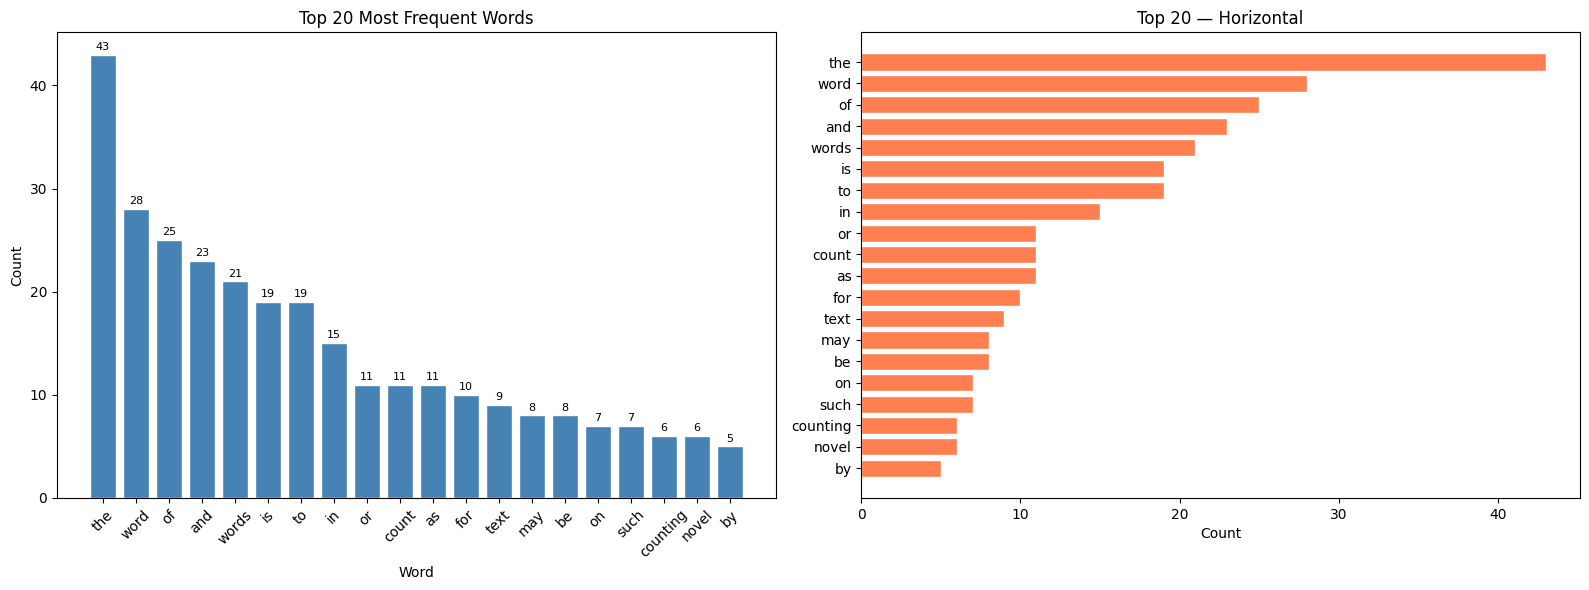

✅ Chart saved


In [13]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Spark aggregates → collect ONLY the top 20 rows (tiny result set)
top20_rows = (
    word_count_df
    .orderBy(F.col('count').desc())
    .limit(20)
    .collect()   # only action — collects 20 Row objects
)

# Unpack using list comprehension (no for loop, Pythonic)
words  = [row['word']  for row in top20_rows]
counts = [row['count'] for row in top20_rows]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(words, counts, color='steelblue', edgecolor='white')
axes[0].bar_label(bars, padding=2, fontsize=8)
axes[0].set_xlabel('Word');  axes[0].set_ylabel('Count')
axes[0].set_title('Top 20 Most Frequent Words')
axes[0].tick_params(axis='x', rotation=45)

# Horizontal bar chart (easier to read)
axes[1].barh(words[::-1], counts[::-1], color='coral', edgecolor='white')
axes[1].set_xlabel('Count'); axes[1].set_title('Top 20 — Horizontal')

plt.tight_layout()
plt.savefig('wordcount_spark.png', dpi=150)
plt.show()
print('✅ Chart saved')

## Step 11 — Save Results using Spark Writer (no pandas to_csv)
> Use `df.coalesce(1).write.csv()` — pure Spark distributed write

In [15]:
import os, csv

output_path = 'output/WordCount_Results.csv'
os.makedirs('output', exist_ok=True)

# Collect sorted results (small data — safe)
rows = word_count_df.orderBy(F.col('count').desc()).collect()

# Write using Python's csv writer
with open(output_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['word', 'count'])       # header
    writer.writerows([(r['word'], r['count']) for r in rows])

print(f'✅ Results written to {output_path}')

✅ Results written to output/WordCount_Results.csv


## Step 12 — Full Pipeline Summary & Stop Spark

In [16]:
# ── Final stats using pure Spark aggregations ─────────────────────────────────
stats = spark.sql("""
    SELECT
        SUM(count)            AS total_words,
        COUNT(DISTINCT word)  AS unique_words,
        MAX(count)            AS highest_freq,
        ROUND(AVG(count), 2)  AS avg_freq
    FROM word_counts
""").collect()[0]

print('='*60)
print('   WORD COUNT MapReduce — COMPLETE PIPELINE SUMMARY')
print('='*60)
print('  PIPELINE STAGES:')
print('    sc.textFile()          → lines  RDD')
print('    .flatMap(split)        → words  RDD')
print('    .map(word → (w,1))     → pairs  RDD')
print('    .reduceByKey(sum)      → counts RDD')
print('    createDataFrame(rdd)   → Spark  DataFrame')
print('    .createTempView()      → Spark  SQL Table')
print()
print('  RESULTS:')
print(f'    Total word tokens : {stats["total_words"]}')
print(f'    Unique words      : {stats["unique_words"]}')
print(f'    Highest frequency : {stats["highest_freq"]}')
print(f'    Average frequency : {stats["avg_freq"]}')
print('='*60)

sc.stop()
print('\n✅ Spark stopped. Done!')

   WORD COUNT MapReduce — COMPLETE PIPELINE SUMMARY
  PIPELINE STAGES:
    sc.textFile()          → lines  RDD
    .flatMap(split)        → words  RDD
    .map(word → (w,1))     → pairs  RDD
    .reduceByKey(sum)      → counts RDD
    createDataFrame(rdd)   → Spark  DataFrame
    .createTempView()      → Spark  SQL Table

  RESULTS:
    Total word tokens : 781
    Unique words      : 357
    Highest frequency : 43
    Average frequency : 2.19

✅ Spark stopped. Done!
